In [1]:
import pandas as pd
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the support ticket dataset

df = pd.read_csv("../data/customer_support_tickets.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 8469
Columns: 17


In [3]:
# Display all column names

print(df.columns.tolist())

['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


In [4]:
print(df.columns.tolist())

['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


In [5]:
# Check the important columns

print("Ticket Type:")
print(df["Ticket Type"].value_counts())

print("\nTicket Priority:")
print(df["Ticket Priority"].value_counts())

print("\nMissing values:")
print(df[["Ticket Description", "Ticket Type", "Ticket Priority"]].isnull().sum())

Ticket Type:
Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

Ticket Priority:
Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

Missing values:
Ticket Description    0
Ticket Type           0
Ticket Priority       0
dtype: int64


In [6]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


df["Cleaned Description"] = df["Ticket Description"].apply(clean_text)

print("Text cleaning completed successfully!")

# Display original and cleaned text
print("\nOriginal:")
print(df["Ticket Description"].iloc[0])

print("\nCleaned:")
print(df["Cleaned Description"].iloc[0])

Text cleaning completed successfully!

Original:
I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.

Cleaned:
im having an issue with the productpurchased please assist your billing zip code is we appreciate that you have requested a website address please double check your email address ive tried troubleshooting steps mentioned in the user manual but the issue persists


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

# Convert ticket descriptions into numerical features
X = tfidf.fit_transform(df["Cleaned Description"])

print("TF-IDF conversion completed successfully!")
print("Number of tickets:", X.shape[0])
print("Number of features:", X.shape[1])

TF-IDF conversion completed successfully!
Number of tickets: 8469
Number of features: 5000


In [8]:
from sklearn.model_selection import train_test_split

# Target variable: Ticket Type
y = df["Ticket Type"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data split completed successfully!")

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Data split completed successfully!
Training samples: 6775
Testing samples: 1694


In [9]:
from sklearn.linear_model import LogisticRegression

# Create the classification model
category_model = LogisticRegression(max_iter=1000)

# Train the model
category_model.fit(X_train, y_train)

print("Ticket Type classification model trained successfully!")

Ticket Type classification model trained successfully!


In [10]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions on the test data
y_pred = category_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Ticket Type Classification Results")
print("=" * 40)
print(f"Accuracy: {accuracy:.4f}")

# Detailed evaluation
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Ticket Type Classification Results
Accuracy: 0.2043

Classification Report:
                      precision    recall  f1-score   support

     Billing inquiry       0.20      0.18      0.19       327
Cancellation request       0.19      0.22      0.20       339
     Product inquiry       0.23      0.23      0.23       328
      Refund request       0.20      0.20      0.20       351
     Technical issue       0.20      0.20      0.20       349

            accuracy                           0.20      1694
           macro avg       0.20      0.20      0.20      1694
        weighted avg       0.20      0.20      0.20      1694



In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=category_model.classes_)

# Plot confusion matrix
plt.figure(figsize=(10, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=category_model.classes_,
    yticklabels=category_model.classes_
)

plt.title("Ticket Type Classification - Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

# Save the visualization
plt.savefig("../outputs/category_confusion_matrix.png", dpi=300)

plt.show()

print("Confusion matrix created successfully!")

ModuleNotFoundError: No module named 'seaborn'

In [12]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


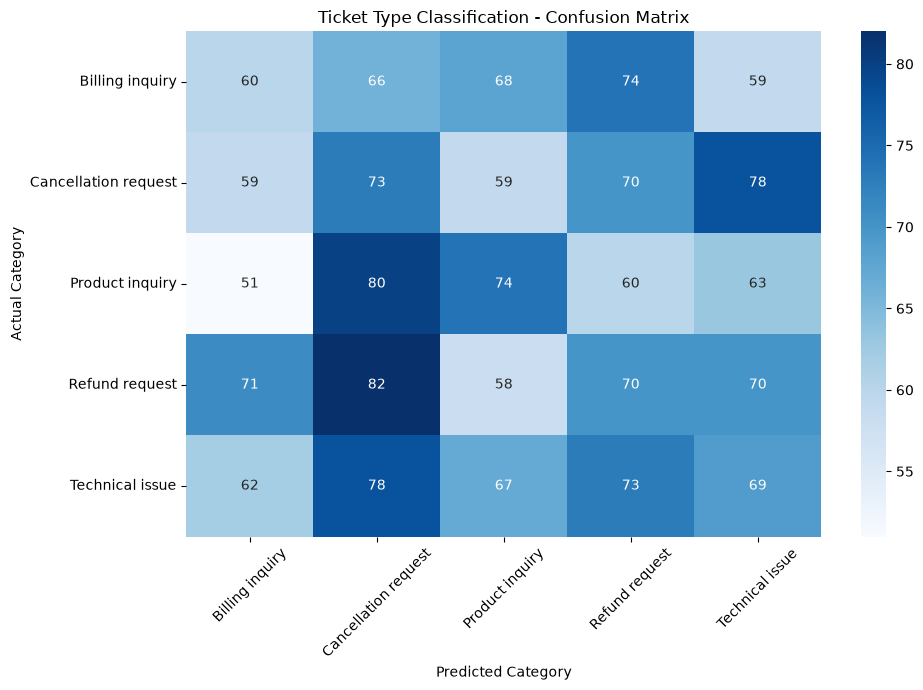

Confusion matrix created successfully!


In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=category_model.classes_
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=category_model.classes_,
    yticklabels=category_model.classes_
)

plt.title("Ticket Type Classification - Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig("../outputs/category_confusion_matrix.png", dpi=300)

plt.show()

print("Confusion matrix created successfully!")

In [14]:
# Prepare the target variable for priority prediction

priority_y = df["Ticket Priority"]

# Split the TF-IDF features into training and testing sets
X_priority_train, X_priority_test, y_priority_train, y_priority_test = train_test_split(
    X,
    priority_y,
    test_size=0.2,
    random_state=42,
    stratify=priority_y
)

print("Priority data split completed successfully!")
print("Training samples:", X_priority_train.shape[0])
print("Testing samples:", X_priority_test.shape[0])

Priority data split completed successfully!
Training samples: 6775
Testing samples: 1694


In [15]:
from sklearn.linear_model import LogisticRegression

# Create the priority classification model
priority_model = LogisticRegression(max_iter=1000)

# Train the model
priority_model.fit(X_priority_train, y_priority_train)

print("Ticket Priority classification model trained successfully!")

Ticket Priority classification model trained successfully!


In [16]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions on the test data
priority_pred = priority_model.predict(X_priority_test)

# Calculate accuracy
priority_accuracy = accuracy_score(
    y_priority_test,
    priority_pred
)

print("Ticket Priority Classification Results")
print("=" * 45)
print(f"Accuracy: {priority_accuracy:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_priority_test,
        priority_pred
    )
)

Ticket Priority Classification Results
Accuracy: 0.2603

Classification Report:
              precision    recall  f1-score   support

    Critical       0.26      0.26      0.26       426
        High       0.27      0.24      0.25       417
         Low       0.24      0.24      0.24       413
      Medium       0.27      0.30      0.28       438

    accuracy                           0.26      1694
   macro avg       0.26      0.26      0.26      1694
weighted avg       0.26      0.26      0.26      1694



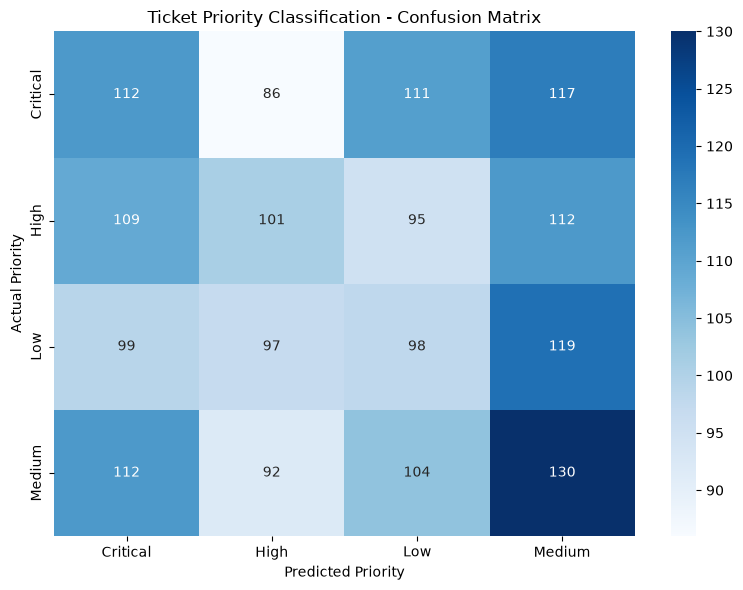

Priority confusion matrix created successfully!


In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
priority_cm = confusion_matrix(
    y_priority_test,
    priority_pred,
    labels=priority_model.classes_
)

# Plot confusion matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    priority_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=priority_model.classes_,
    yticklabels=priority_model.classes_
)

plt.title("Ticket Priority Classification - Confusion Matrix")
plt.xlabel("Predicted Priority")
plt.ylabel("Actual Priority")
plt.tight_layout()

# Save the visualization
plt.savefig(
    "../outputs/priority_confusion_matrix.png",
    dpi=300
)

plt.show()

print("Priority confusion matrix created successfully!")

In [18]:
# Test the complete system with a new support ticket

new_ticket = [
    "I was charged twice for my subscription and I need a refund immediately."
]

# Clean the new ticket
cleaned_ticket = [clean_text(new_ticket[0])]

# Convert the ticket using the existing TF-IDF vectorizer
ticket_features = tfidf.transform(cleaned_ticket)

# Predict ticket type
predicted_type = category_model.predict(ticket_features)[0]

# Predict ticket priority
predicted_priority = priority_model.predict(ticket_features)[0]

print("===== SUPPORT TICKET PREDICTION =====")
print("Ticket:", new_ticket[0])
print("Predicted Ticket Type:", predicted_type)
print("Predicted Priority:", predicted_priority)

===== SUPPORT TICKET PREDICTION =====
Ticket: I was charged twice for my subscription and I need a refund immediately.
Predicted Ticket Type: Product inquiry
Predicted Priority: Critical


In [19]:
def predict_ticket(ticket_text):
    # Clean the ticket
    cleaned_text = clean_text(ticket_text)

    # Convert text to TF-IDF features
    ticket_features = tfidf.transform([cleaned_text])

    # Predict category
    predicted_type = category_model.predict(ticket_features)[0]

    # Predict priority
    predicted_priority = priority_model.predict(ticket_features)[0]

    return predicted_type, predicted_priority

In [20]:
ticket = "My account is not working and I cannot log in."

ticket_type, ticket_priority = predict_ticket(ticket)

print("===== SUPPORT TICKET PREDICTION =====")
print("Ticket:", ticket)
print("Predicted Ticket Type:", ticket_type)
print("Predicted Priority:", ticket_priority)

===== SUPPORT TICKET PREDICTION =====
Ticket: My account is not working and I cannot log in.
Predicted Ticket Type: Technical issue
Predicted Priority: Low


In [21]:
ticket = "I was charged twice for my order and want my money back."

ticket_type, ticket_priority = predict_ticket(ticket)

print("Ticket:", ticket)
print("Predicted Ticket Type:", ticket_type)
print("Predicted Priority:", ticket_priority)

Ticket: I was charged twice for my order and want my money back.
Predicted Ticket Type: Product inquiry
Predicted Priority: Low


In [22]:
# Save model evaluation results

from sklearn.metrics import accuracy_score

category_accuracy = accuracy_score(y_test, y_pred)
priority_accuracy = accuracy_score(y_priority_test, priority_pred)

evaluation_results = pd.DataFrame({
    "Task": [
        "Ticket Type Classification",
        "Ticket Priority Classification"
    ],
    "Model": [
        "Logistic Regression",
        "Logistic Regression"
    ],
    "Accuracy": [
        category_accuracy,
        priority_accuracy
    ]
})

print(evaluation_results)

                             Task                Model  Accuracy
0      Ticket Type Classification  Logistic Regression  0.204250
1  Ticket Priority Classification  Logistic Regression  0.260331


In [23]:
evaluation_results.to_csv(
    "../outputs/model_evaluation.csv",
    index=False
)

print("Model evaluation results saved successfully!")

Model evaluation results saved successfully!


In [24]:
business_summary = """
SUPPORT TICKET CLASSIFICATION & PRIORITIZATION
================================================

Project Purpose:
This machine learning system automatically analyzes customer support
tickets and predicts both the ticket category and priority level.

How It Works:
1. Customer submits a support ticket.
2. The ticket description is cleaned using text preprocessing.
3. TF-IDF converts the text into numerical features.
4. A Logistic Regression model predicts the ticket type.
5. A second Logistic Regression model predicts the ticket priority.

Ticket Categories:
- Refund request
- Technical issue
- Cancellation request
- Product inquiry
- Billing inquiry

Priority Levels:
- Critical
- High
- Medium
- Low

Business Benefits:
- Reduces manual ticket sorting.
- Helps support teams identify important tickets faster.
- Improves ticket organization.
- Helps reduce support backlog.
- Allows support teams to focus on solving customer problems.
- Supports faster and more consistent customer service.

Machine Learning Approach:
- Text preprocessing
- TF-IDF feature extraction
- Logistic Regression classification
- Accuracy, Precision, Recall and F1-score evaluation
- Confusion matrix analysis

The system can be extended in the future with:
- Advanced NLP models
- Automated email/ticket integration
- Real-time ticket classification
- Dashboard visualization
- Human-in-the-loop review for uncertain predictions
"""

print(business_summary)


SUPPORT TICKET CLASSIFICATION & PRIORITIZATION

Project Purpose:
This machine learning system automatically analyzes customer support
tickets and predicts both the ticket category and priority level.

How It Works:
1. Customer submits a support ticket.
2. The ticket description is cleaned using text preprocessing.
3. TF-IDF converts the text into numerical features.
4. A Logistic Regression model predicts the ticket type.
5. A second Logistic Regression model predicts the ticket priority.

Ticket Categories:
- Refund request
- Technical issue
- Cancellation request
- Product inquiry
- Billing inquiry

Priority Levels:
- Critical
- High
- Medium
- Low

Business Benefits:
- Reduces manual ticket sorting.
- Helps support teams identify important tickets faster.
- Improves ticket organization.
- Helps reduce support backlog.
- Allows support teams to focus on solving customer problems.
- Supports faster and more consistent customer service.

Machine Learning Approach:
- Text preprocessing

In [25]:
    with open("../outputs/business_summary.txt", "w", encoding="utf-8") as file:
    file.write(business_summary)

print("Business summary saved successfully!")

IndentationError: unexpected indent (258149159.py, line 1)

In [26]:
 with open("../outputs/business_summary.txt", "w", encoding="utf-8") as file:
    file.write(business_summary)

print("Business summary saved successfully!")

IndentationError: unexpected indent (1081123023.py, line 1)

In [27]:
with open("../outputs/business_summary.txt", "w", encoding="utf-8") as file:
    file.write(business_summary)

print("Business summary saved successfully!")

Business summary saved successfully!


In [28]:
Get-Content requirements.txt

SyntaxError: invalid syntax (1653894578.py, line 1)